# Retail Sales Analysis with Python

**Bluestock Fintech Internship — Week 1**  
**Prepared by:** Efigénia Wandi Filipe Gabriel  
**Updated:** 10 September 2026  
**Input:** `Raw_Sales_Dataset.csv`  

## Objective

Load a raw CSV file, clean and validate the data, calculate business KPIs, analyse customer and product performance, and create simple visualisations with Pandas, NumPy and Matplotlib.

> This notebook uses a simulated retail sales training dataset. It does not contain Bluestock customer or operational data.


## 1. Import libraries and load the CSV

- `Path` handles the file location.
- `Pandas` loads and analyses tabular data.
- `NumPy` supports numerical calculations and validation.
- `Matplotlib` creates the charts.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
pd.options.display.float_format = '{:,.2f}'.format

candidate_paths = [
    Path('Raw_Sales_Dataset.csv'),
    Path('outputs/bluestock_week1/Raw_Sales_Dataset.csv'),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Raw_Sales_Dataset.csv was not found. Place it in the same folder as this notebook.'
    )

raw_df = pd.read_csv(DATA_PATH)
print(f'File loaded: {DATA_PATH}')
print(f'Raw shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns')
print('\nFirst five records:')
print(raw_df.head().to_string(index=False))


File loaded: outputs/bluestock_week1/Raw_Sales_Dataset.csv
Raw shape: 506 rows x 15 columns

First five records:
Order ID Order Date Customer ID    Customer Name        Segment    City Region Product ID          Product Name        Category  Quantity  Unit Price  Discount Payment Method Order Status
ORD-0001 2025-10-14     CUS-027     Kabir Khan 2 Small Business  Mumbai   West    PRD-003             USB-C Hub     Electronics         1        1899      0.05    Net Banking    Completed
ORD-0002 2025-09-03     CUS-026     Isha Mehta 2      Corporate  Jaipur  North    PRD-008 Storage Container Set  Home & Kitchen         1         999      0.00    Credit Card     Returned
ORD-0003 2025-04-04     CUS-079 Siddharth Jain 4       Consumer Kolkata   East    PRD-004          Laptop Stand Office Supplies         5        1299      0.20            UPI    Completed
ORD-0004 2025-01-02     CUS-041   Aarav Sharma 3      Corporate    Pune   West    PRD-011        Classic Wallet         Fashion        

## 2. Python basics and preparation

This section demonstrates variables, lists, dictionaries and loops. The product and city dictionaries act as small reference tables used to correct inconsistent values.


In [2]:
# A variable stores one reusable value.
completed_status = 'Completed'

# A list stores several related values in a defined order.
numeric_columns = ['quantity', 'unit_price', 'discount']

# Dictionaries connect a key, such as Product ID, to trusted reference values.
product_master = {
    'PRD-001': {'product_name': 'Wireless Mouse', 'category': 'Electronics', 'unit_cost': 540},
    'PRD-002': {'product_name': 'Bluetooth Headphones', 'category': 'Electronics', 'unit_cost': 1620},
    'PRD-003': {'product_name': 'USB-C Hub', 'category': 'Electronics', 'unit_cost': 1180},
    'PRD-004': {'product_name': 'Laptop Stand', 'category': 'Office Supplies', 'unit_cost': 760},
    'PRD-005': {'product_name': 'Executive Notebook', 'category': 'Office Supplies', 'unit_cost': 170},
    'PRD-006': {'product_name': 'Desk Organiser', 'category': 'Office Supplies', 'unit_cost': 390},
    'PRD-007': {'product_name': 'Electric Kettle', 'category': 'Home & Kitchen', 'unit_cost': 1040},
    'PRD-008': {'product_name': 'Storage Container Set', 'category': 'Home & Kitchen', 'unit_cost': 580},
    'PRD-009': {'product_name': 'Table Lamp', 'category': 'Home & Kitchen', 'unit_cost': 920},
    'PRD-010': {'product_name': 'Travel Backpack', 'category': 'Fashion', 'unit_cost': 1380},
    'PRD-011': {'product_name': 'Classic Wallet', 'category': 'Fashion', 'unit_cost': 690},
    'PRD-012': {'product_name': 'Stainless Water Bottle', 'category': 'Lifestyle', 'unit_cost': 410},
}

city_region = {
    'Lucknow': 'North', 'Delhi': 'North', 'Jaipur': 'North',
    'Mumbai': 'West', 'Pune': 'West', 'Ahmedabad': 'West',
    'Bengaluru': 'South', 'Chennai': 'South', 'Hyderabad': 'South',
    'Kolkata': 'East',
}

df = raw_df.copy()
df.columns = [
    column.strip().lower().replace(' ', '_').replace('.', '')
    for column in df.columns
]

quality_before = {
    'Total rows': len(df),
    'Exact duplicate rows': int(df.duplicated().sum()),
    'Missing customer names': int(df['customer_name'].isna().sum()),
    'Missing discounts': int(df['discount'].isna().sum()),
    'Non-standard category labels': int((df['category'] == 'Electronic').sum()),
    'Regions with extra spaces': int((df['region'] != df['region'].str.strip()).sum()),
    'Non-standard UPI labels': int((df['payment_method'] == 'upi').sum()),
}

for issue, count in quality_before.items():
    print(f'{issue}: {count}')


Total rows: 506
Exact duplicate rows: 6
Missing customer names: 6
Missing discounts: 4
Non-standard category labels: 1
Regions with extra spaces: 3
Non-standard UPI labels: 2


## 3. Clean and transform the data

The cleaning process removes exact duplicates, restores missing customer names, standardises labels, converts dates and numbers to the correct data types, and calculates the financial fields.


In [3]:
# 1. Remove six exact duplicate rows.
df = df.drop_duplicates().copy()

# 2. Remove unnecessary spaces from text fields.
text_columns = df.select_dtypes(include='object').columns
for column in text_columns:
    df[column] = df[column].str.strip()

# 3. Recover missing customer names using other rows with the same Customer ID.
customer_name_lookup = (
    df.dropna(subset=['customer_name'])
      .groupby('customer_id')['customer_name']
      .first()
)
df['customer_name'] = df['customer_name'].fillna(
    df['customer_id'].map(customer_name_lookup)
)

# 4. Convert blank discounts to 0 and ensure numerical data types.
df['discount'] = df['discount'].fillna(0)
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='raise')

# 5. Convert the order date from text into a real date.
df['order_date'] = pd.to_datetime(df['order_date'], errors='raise')

# 6. Use trusted dictionaries to standardise product and region information.
df['product_name'] = df['product_id'].map(
    {key: value['product_name'] for key, value in product_master.items()}
)
df['category'] = df['product_id'].map(
    {key: value['category'] for key, value in product_master.items()}
)
df['unit_cost'] = df['product_id'].map(
    {key: value['unit_cost'] for key, value in product_master.items()}
)
df['region'] = df['city'].map(city_region)
df['payment_method'] = df['payment_method'].replace({'upi': 'UPI'})

# 7. Calculate revenue, cost and profit only for completed orders.
is_completed = df['order_status'].eq(completed_status)
df['revenue'] = np.where(
    is_completed,
    df['quantity'] * df['unit_price'] * (1 - df['discount']),
    0,
).round(2)
df['total_cost'] = np.where(
    is_completed,
    df['quantity'] * df['unit_cost'],
    0,
).round(2)
df['profit'] = (df['revenue'] - df['total_cost']).round(2)
df['month'] = df['order_date'].dt.strftime('%b %Y')
df['year'] = df['order_date'].dt.year

clean_column_order = [
    'order_id', 'order_date', 'customer_id', 'customer_name', 'segment',
    'city', 'region', 'product_id', 'product_name', 'category', 'quantity',
    'unit_price', 'discount', 'revenue', 'unit_cost', 'total_cost', 'profit',
    'payment_method', 'order_status', 'month', 'year',
]
df = df[clean_column_order].sort_values('order_id').reset_index(drop=True)

print(f'Clean shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(df.head().to_string(index=False))


Clean shape: 500 rows x 21 columns
order_id order_date customer_id    customer_name        segment    city region product_id          product_name        category  quantity  unit_price  discount  revenue  unit_cost  total_cost   profit payment_method order_status    month  year
ORD-0001 2025-10-14     CUS-027     Kabir Khan 2 Small Business  Mumbai   West    PRD-003             USB-C Hub     Electronics         1        1899      0.05 1,804.05       1180        1180   624.05    Net Banking    Completed Oct 2025  2025
ORD-0002 2025-09-03     CUS-026     Isha Mehta 2      Corporate  Jaipur  North    PRD-008 Storage Container Set  Home & Kitchen         1         999      0.00     0.00        580           0     0.00    Credit Card     Returned Sep 2025  2025
ORD-0003 2025-04-04     CUS-079 Siddharth Jain 4       Consumer Kolkata   East    PRD-004          Laptop Stand Office Supplies         5        1299      0.20 5,196.00        760        3800 1,396.00            UPI    Completed Apr 

In [4]:
# Final quality checks after cleaning.
valid_regions = {'North', 'South', 'East', 'West'}
valid_categories = {
    'Electronics', 'Office Supplies', 'Home & Kitchen', 'Fashion', 'Lifestyle'
}

quality_after = {
    'Total rows': len(df),
    'Exact duplicate rows': int(df.duplicated().sum()),
    'Missing customer names': int(df['customer_name'].isna().sum()),
    'Missing discounts': int(df['discount'].isna().sum()),
    'Non-standard category labels': int((~df['category'].isin(valid_categories)).sum()),
    'Regions with extra spaces': int((df['region'] != df['region'].str.strip()).sum()),
    'Non-standard UPI labels': int((df['payment_method'] == 'upi').sum()),
}

quality_comparison = pd.DataFrame({
    'Quality check': list(quality_before.keys()),
    'Before cleaning': list(quality_before.values()),
    'After cleaning': [quality_after[key] for key in quality_before],
})
print(quality_comparison.to_string(index=False))

assert len(df) == 500
assert df['order_id'].is_unique
assert df.isna().sum().sum() == 0
assert set(df['region']) == valid_regions
assert set(df['category']) == valid_categories
assert df['discount'].between(0, 1).all()

# File handling: export the cleaned result produced by this notebook.
CLEAN_OUTPUT_PATH = DATA_PATH.with_name('Python_Cleaned_Sales_Dataset.csv')
df.to_csv(CLEAN_OUTPUT_PATH, index=False)
print(f'\nAll cleaning checks passed.')
print(f'Clean dataset exported to: {CLEAN_OUTPUT_PATH}')


               Quality check  Before cleaning  After cleaning
                  Total rows              506             500
        Exact duplicate rows                6               0
      Missing customer names                6               0
           Missing discounts                4               0
Non-standard category labels                1               0
   Regions with extra spaces                3               0
     Non-standard UPI labels                2               0

All cleaning checks passed.
Clean dataset exported to: outputs/bluestock_week1/Python_Cleaned_Sales_Dataset.csv


## 4. Calculate the main business KPIs

A function groups the KPI logic in one reusable block. It returns a dictionary, and a loop prints each result.


In [5]:
def calculate_kpis(data):
    completed = data[data['order_status'].eq(completed_status)].copy()
    total_revenue = completed['revenue'].sum()
    total_profit = completed['profit'].sum()

    return {
        'Completed orders': int(completed['order_id'].nunique()),
        'Total revenue (INR)': round(total_revenue, 2),
        'Total profit (INR)': round(total_profit, 2),
        'Profit margin (%)': round(100 * total_profit / total_revenue, 2),
        'Average order value (INR)': round(completed['revenue'].mean(), 2),
    }

kpis = calculate_kpis(df)
for metric, value in kpis.items():
    print(f'{metric}: {value:,.2f}' if isinstance(value, float) else f'{metric}: {value:,}')


Completed orders: 323
Total revenue (INR): 1,164,270.85
Total profit (INR): 397,040.85
Profit margin (%): 34.10
Average order value (INR): 3,604.55


In [6]:
# NumPy verifies that Python matches the Excel dashboard and SQL analysis.
expected_kpis = {
    'Completed orders': 323,
    'Total revenue (INR)': 1164270.85,
    'Total profit (INR)': 397040.85,
    'Profit margin (%)': 34.10,
    'Average order value (INR)': 3604.55,
}

validation_results = {
    metric: bool(np.isclose(kpis[metric], expected, atol=0.01))
    for metric, expected in expected_kpis.items()
}

for metric, passed in validation_results.items():
    print(f'{metric}: {"PASS" if passed else "CHECK"}')

assert all(validation_results.values())


Completed orders: PASS
Total revenue (INR): PASS
Total profit (INR): PASS
Profit margin (%): PASS
Average order value (INR): PASS


## 5. Descriptive statistics and outlier detection

Mean, median, mode and standard deviation describe the distribution of completed-order revenue. The IQR method identifies unusually high-value orders without deleting them, because they are valid business transactions.


In [7]:
completed = df[df['order_status'].eq(completed_status)].copy()

q1, q3 = np.percentile(completed['revenue'], [25, 75])
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
outliers = completed[
    (completed['revenue'] < lower_limit) |
    (completed['revenue'] > upper_limit)
]

revenue_statistics = pd.Series({
    'Mean': completed['revenue'].mean(),
    'Median': completed['revenue'].median(),
    'Mode': completed['revenue'].mode().iloc[0],
    'Standard deviation': completed['revenue'].std(),
    'Minimum': completed['revenue'].min(),
    'Maximum': completed['revenue'].max(),
    'IQR lower limit': lower_limit,
    'IQR upper limit': upper_limit,
    'Valid high-value outliers': len(outliers),
})
print(revenue_statistics.round(2).to_string())


Mean                         3,604.55
Median                       2,970.75
Mode                         2,796.00
Standard deviation           2,535.49
Minimum                        279.20
Maximum                     11,245.50
IQR lower limit             -3,408.80
IQR upper limit              9,943.20
Valid high-value outliers        9.00


## 6. Monthly trend

The records are grouped by month to compare revenue, profit and the number of completed orders over time.


In [8]:
monthly_performance = (
    completed
    .assign(sales_month=completed['order_date'].dt.to_period('M'))
    .groupby('sales_month', as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
        completed_orders=('order_id', 'nunique'),
    )
    .sort_values('sales_month')
)
monthly_performance['month_over_month_revenue_pct'] = (
    monthly_performance['revenue'].pct_change() * 100
)
monthly_performance['sales_month'] = monthly_performance['sales_month'].astype(str)
print(monthly_performance.round(2).to_string(index=False))


sales_month    revenue    profit  completed_orders  month_over_month_revenue_pct
    2025-01 122,677.05 42,087.05                32                           NaN
    2025-02 103,017.70 34,277.70                25                        -16.03
    2025-03  93,364.90 30,614.90                28                         -9.37
    2025-04  87,274.95 30,314.95                22                         -6.52
    2025-05  92,750.65 32,530.65                27                          6.27
    2025-06  56,500.05 19,270.05                17                        -39.08
    2025-07 108,386.30 35,336.30                33                         91.83
    2025-08  69,116.95 23,826.95                20                        -36.23
    2025-09 122,483.05 41,543.05                34                         77.21
    2025-10 123,896.25 44,946.25                34                          1.15
    2025-11  67,695.20 22,985.20                23                        -45.36
    2025-12 117,107.80 39,30

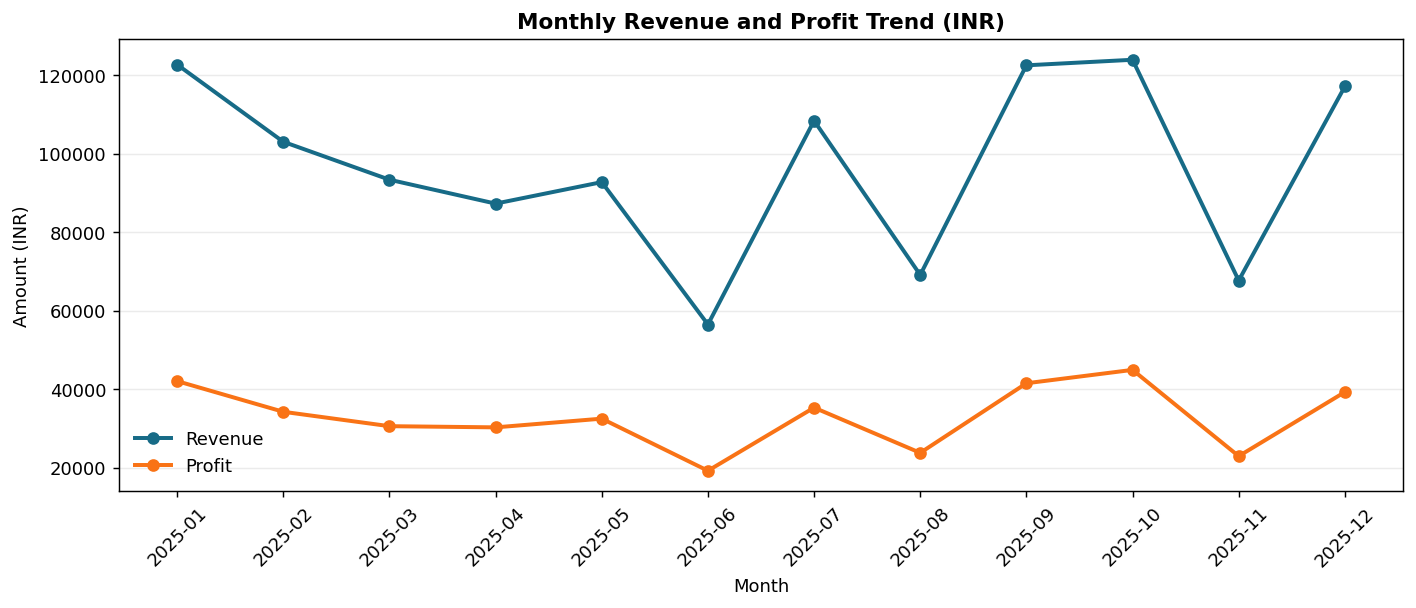

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(monthly_performance['sales_month'], monthly_performance['revenue'],
        marker='o', linewidth=2.2, color='#176B87', label='Revenue')
ax.plot(monthly_performance['sales_month'], monthly_performance['profit'],
        marker='o', linewidth=2.2, color='#F97316', label='Profit')
ax.set_title('Monthly Revenue and Profit Trend (INR)', weight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount (INR)')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()


## 7. Category, region and product performance

These summaries identify where revenue and profit come from and which products perform best.


In [10]:
category_performance = (
    completed.groupby('category', as_index=False)
    .agg(
        completed_orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
    )
    .sort_values('revenue', ascending=False)
)
category_performance['margin_pct'] = (
    100 * category_performance['profit'] / category_performance['revenue']
)

region_performance = (
    completed.groupby('region', as_index=False)
    .agg(
        completed_orders=('order_id', 'nunique'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
    )
    .sort_values('revenue', ascending=False)
)
region_performance['margin_pct'] = (
    100 * region_performance['profit'] / region_performance['revenue']
)

product_performance = (
    completed.groupby(['product_id', 'product_name', 'category'], as_index=False)
    .agg(
        completed_orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
    )
    .sort_values('revenue', ascending=False)
)

print('CATEGORY PERFORMANCE')
print(category_performance.round(2).to_string(index=False))
print('\nREGION PERFORMANCE')
print(region_performance.round(2).to_string(index=False))
print('\nTOP FIVE PRODUCTS')
print(product_performance.head(5).round(2).to_string(index=False))


CATEGORY PERFORMANCE
       category  completed_orders  units_sold    revenue     profit  margin_pct
    Electronics                86         230 372,756.75 112,596.75       30.21
 Home & Kitchen                86         264 350,186.00 120,726.00       34.47
        Fashion                51         143 235,016.75  81,836.75       34.82
Office Supplies                77         236 160,129.15  61,119.15       38.17
      Lifestyle                23          62  46,182.20  20,762.20       44.96

REGION PERFORMANCE
region  completed_orders    revenue     profit  margin_pct
 North               112 391,129.05 135,889.05       34.74
 South                93 368,849.40 124,839.40       33.85
  West                86 311,891.75 105,151.75       33.71
  East                32  92,400.65  31,160.65       33.72

TOP FIVE PRODUCTS
product_id         product_name       category  completed_orders  units_sold    revenue    profit
   PRD-010      Travel Backpack        Fashion                28   

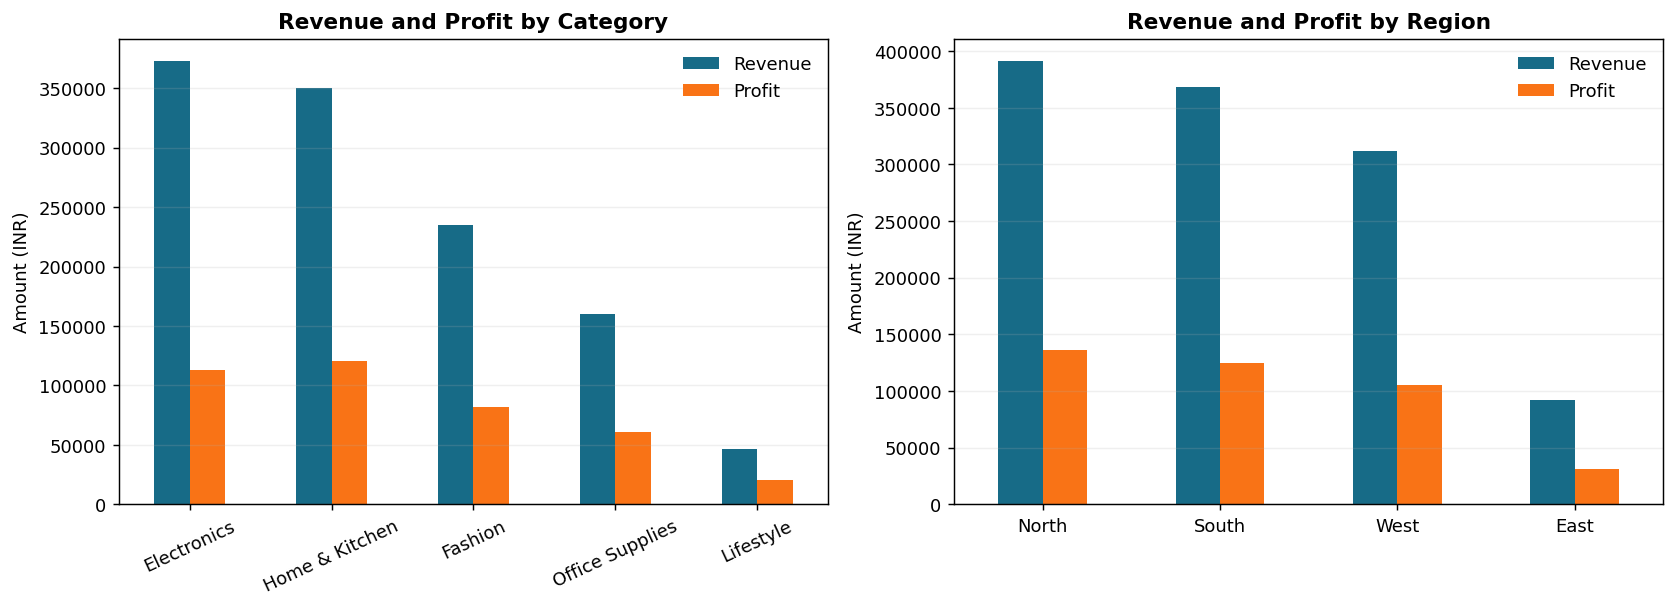

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

category_plot = category_performance.set_index('category')[['revenue', 'profit']]
category_plot.plot(kind='bar', ax=axes[0], color=['#176B87', '#F97316'])
axes[0].set_title('Revenue and Profit by Category', weight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Amount (INR)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(['Revenue', 'Profit'], frameon=False)
axes[0].grid(axis='y', alpha=0.2)

region_plot = region_performance.set_index('region')[['revenue', 'profit']]
region_plot.plot(kind='bar', ax=axes[1], color=['#176B87', '#F97316'])
axes[1].set_title('Revenue and Profit by Region', weight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount (INR)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Revenue', 'Profit'], frameon=False)
axes[1].grid(axis='y', alpha=0.2)

fig.tight_layout()
plt.show()


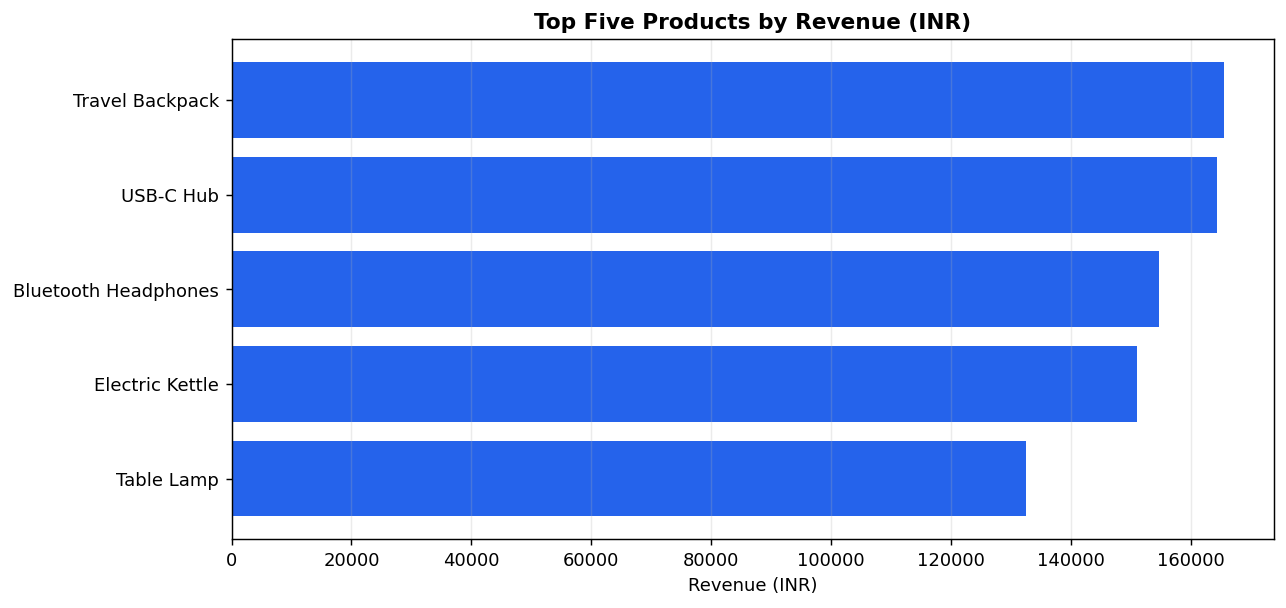

In [12]:
top_products = product_performance.head(5).sort_values('revenue')
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(top_products['product_name'], top_products['revenue'], color='#2563EB')
ax.set_title('Top Five Products by Revenue (INR)', weight='bold')
ax.set_xlabel('Revenue (INR)')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()


## 8. Correlation analysis

Correlation measures how strongly two numerical variables move together. Values close to `1` indicate a positive relationship, values close to `-1` indicate a negative relationship, and values near `0` indicate a weak linear relationship.


            quantity  unit_price  discount  revenue  unit_cost  profit
quantity        1.00       -0.04      0.00     0.69      -0.04    0.71
unit_price     -0.04        1.00      0.01     0.61       1.00    0.48
discount        0.00        0.01      1.00    -0.10       0.01   -0.33
revenue         0.69        0.61     -0.10     1.00       0.61    0.95
unit_cost      -0.04        1.00      0.01     0.61       1.00    0.48
profit          0.71        0.48     -0.33     0.95       0.48    1.00


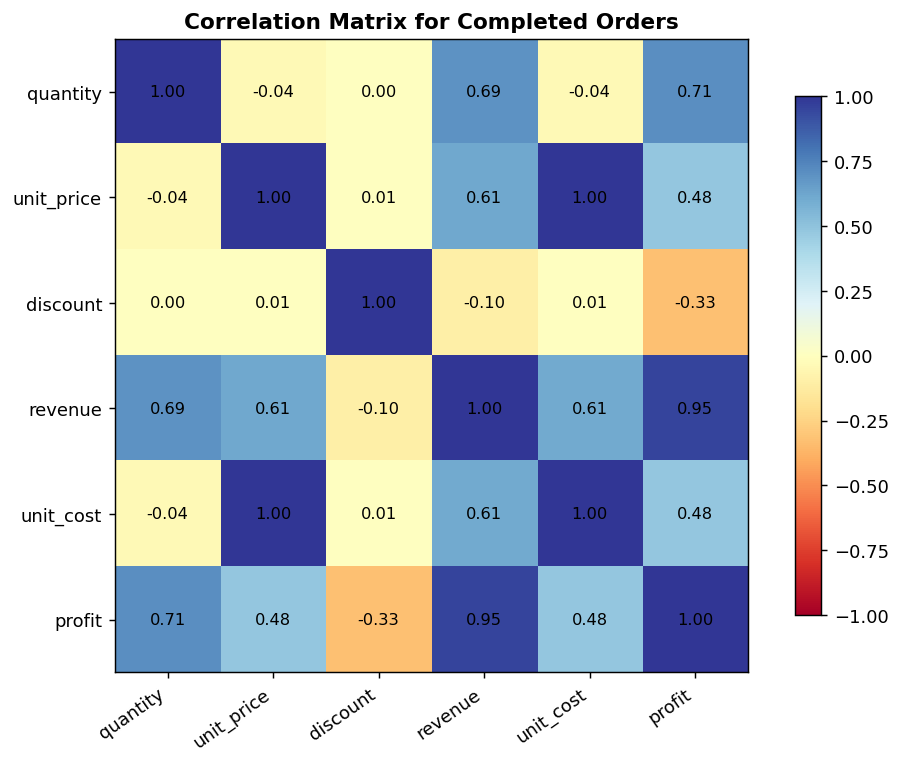

In [13]:
correlation_columns = [
    'quantity', 'unit_price', 'discount', 'revenue', 'unit_cost', 'profit'
]
correlation_matrix = completed[correlation_columns].corr()
print(correlation_matrix.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation_matrix, cmap='RdYlBu', vmin=-1, vmax=1)
fig.colorbar(image, ax=ax, shrink=0.82)
ax.set_xticks(range(len(correlation_columns)), correlation_columns,
              rotation=35, ha='right')
ax.set_yticks(range(len(correlation_columns)), correlation_columns)
for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        value = correlation_matrix.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Correlation Matrix for Completed Orders', weight='bold')
fig.tight_layout()
plt.show()


## 9. Key business insights

The conclusions below are generated directly from the calculated tables, avoiding manually typed results that could become outdated.


In [14]:
top_category = category_performance.iloc[0]
top_region = region_performance.iloc[0]
top_product = product_performance.iloc[0]
peak_month = monthly_performance.loc[monthly_performance['revenue'].idxmax()]

insights = [
    f"Electronics generated the highest category revenue: INR {top_category['revenue']:,.2f}.",
    f"North was the highest-revenue region: INR {top_region['revenue']:,.2f}.",
    f"{top_product['product_name']} was the highest-revenue product: INR {top_product['revenue']:,.2f}.",
    f"The peak sales month was {peak_month['sales_month']}: INR {peak_month['revenue']:,.2f} revenue.",
    f"Overall profit margin was {kpis['Profit margin (%)']:.2f}%.",
    f"The cleaned dataset contains {len(df):,} unique orders and no unresolved missing values.",
]

for number, insight in enumerate(insights, start=1):
    print(f'{number}. {insight}')


1. Electronics generated the highest category revenue: INR 372,756.75.
2. North was the highest-revenue region: INR 391,129.05.
3. Travel Backpack was the highest-revenue product: INR 165,474.75.
4. The peak sales month was 2025-10: INR 123,896.25 revenue.
5. Overall profit margin was 34.10%.
6. The cleaned dataset contains 500 unique orders and no unresolved missing values.


## 10. Conclusion

The notebook loaded 506 raw records, resolved the controlled data-quality issues and produced 500 clean, unique orders. It calculated the same KPIs as the Excel dashboard and SQL analysis, created monthly, category, region and product summaries, and generated four analytical visualisations.

The results demonstrate the complete Python workflow requested for Week 1: file handling, Python fundamentals, Pandas, NumPy, Matplotlib, cleaning, KPI calculation and business analysis.
